In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [3]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

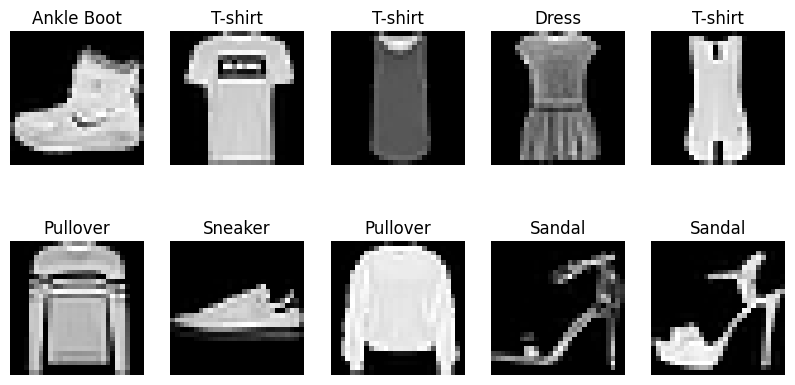

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [6]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

datagen.fit(X_train)

In [7]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.8651 - loss: 0.3694 - val_accuracy: 0.8860 - val_loss: 0.3005
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 75ms/step - accuracy: 0.8681 - loss: 0.3598 - val_accuracy: 0.8886 - val_loss: 0.2951
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.8687 - loss: 0.3569 - val_accuracy: 0.8914 - val_loss: 0.2945
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - accuracy: 0.8704 - loss: 0.3539 - val_accuracy: 0.8949 - val_loss: 0.2886
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.8696 - loss: 0.3529 - val_accuracy: 0.8914 - val_loss: 0.2920
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.8730 - loss: 0.3478 - val_accuracy: 0.8931 - val_loss: 0.2887
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.8725 - loss: 0.3497 - val_accuracy: 0.8939 - val_loss: 0.2844
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.8737 - loss: 0.3423 - 

In [12]:
loss,accuracy=model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8941 - loss: 0.2908
Test Accuracy: 0.89410001039505


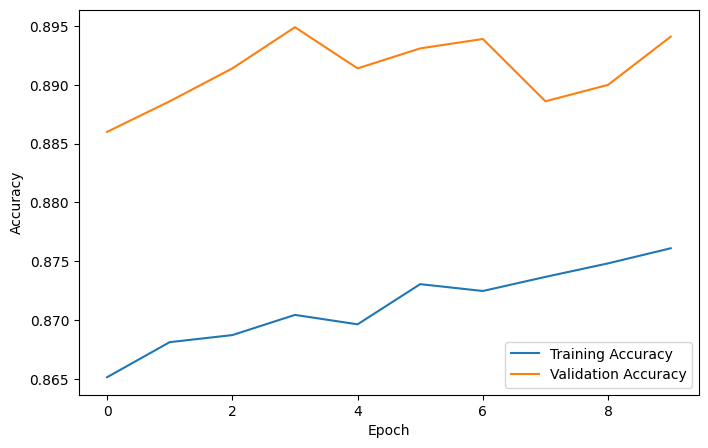

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

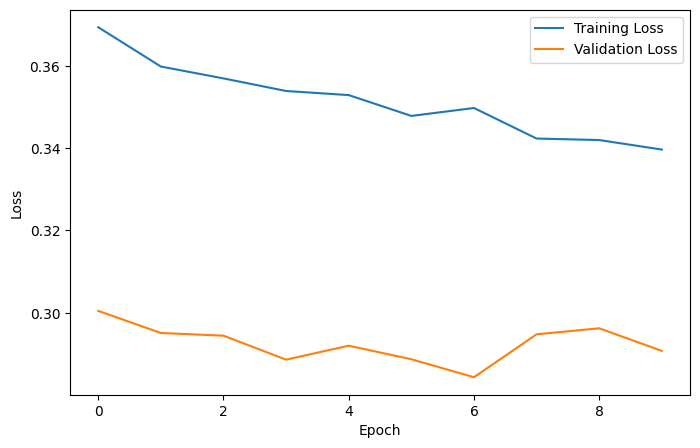

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
predictions=model.predict(X_test)

predicted_classes=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [16]:
print(classification_report(y_test,predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

     T-shirt       0.84      0.86      0.85      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.81      0.89      0.85      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.88      0.75      0.81      1000
      Sandal       0.95      0.99      0.97      1000
       Shirt       0.69      0.70      0.70      1000
     Sneaker       0.96      0.92      0.94      1000
         Bag       0.97      0.98      0.98      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



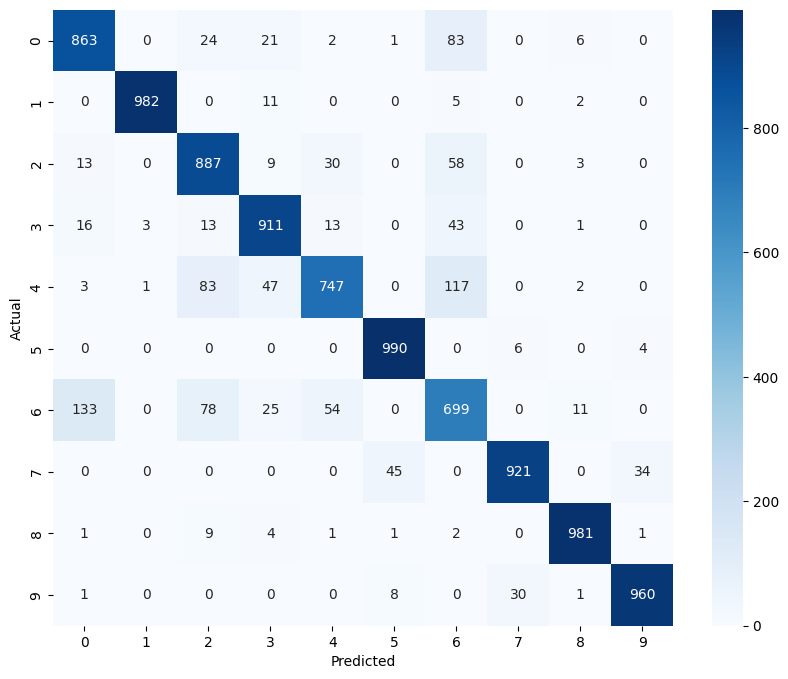

In [17]:
cm=confusion_matrix(y_test,predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

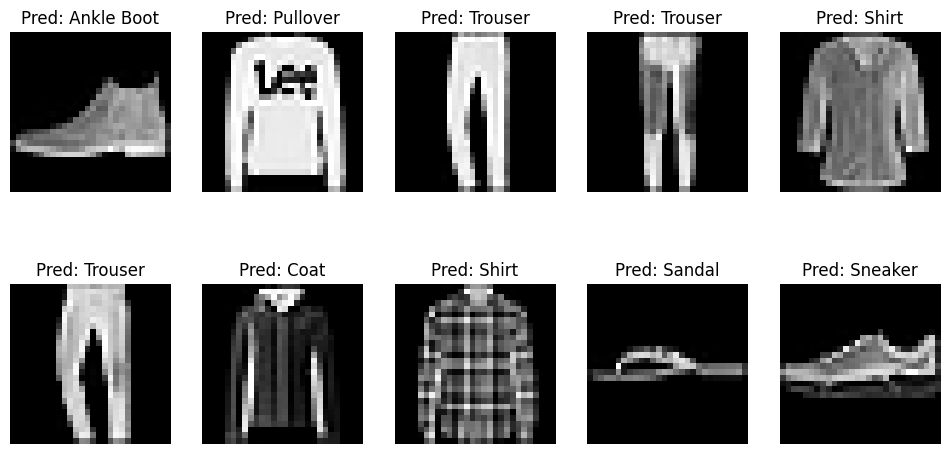

In [18]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28),cmap='gray')

    plt.title("Pred: "+class_names[predicted_classes[i]])

    plt.axis("off")

plt.show()

In [21]:
model.save("fashion_mnist_model.keras")

In [22]:
saved_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8941 - loss: 0.2908


[0.29075610637664795, 0.89410001039505]